# Rotary plotting

Plots for processed rotary CSVs produced by `rotary_analysis.ipynb`.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import (
    ggplot, aes, geom_rect, geom_ribbon, geom_line, geom_text, geom_vline, geom_hline, facet_wrap,
    scale_fill_manual, scale_x_continuous, scale_color_manual, theme_gray, theme, labs,
    element_text, element_blank, element_line, element_rect
)

from CalciumKit.behavior import mean_in_epoch


In [ ]:
# Folder containing raw rotary CSVs processed by rotary_analysis.ipynb
input_dir = Path('/Users/suthardr/Desktop/Rotary/Recall2')

processed_dir = input_dir / "processed"
plot_dir = processed_dir / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)


## Plot the average velocity trace for the whole session (all mice)

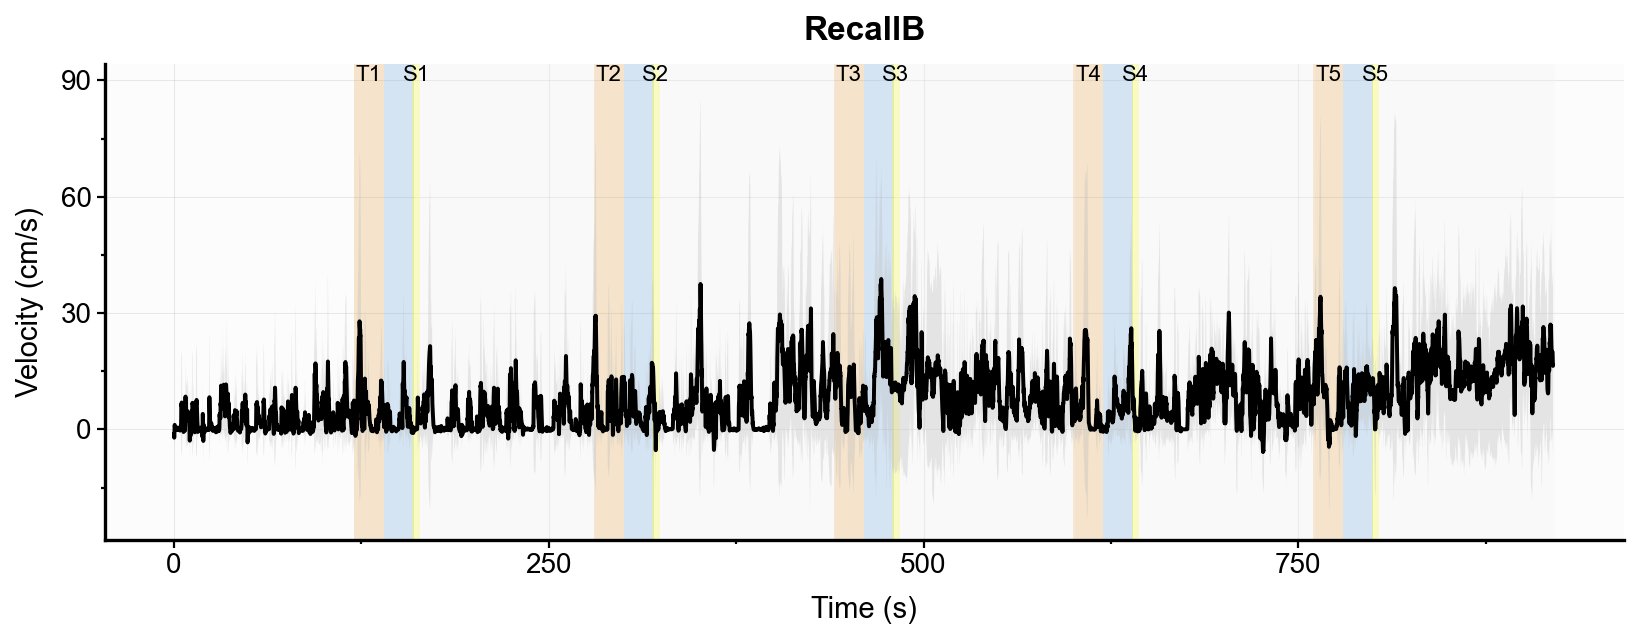

In [64]:
def plot_full_session_plotnine():
    files = sorted(processed_dir.glob("processedRotary_*.csv"))
    files = [f for f in files if "phoebe" not in f.stem]
    common_t = np.arange(0, 920, 0.01)

    all_vel = np.array([
        np.interp(common_t, df["time_s"], df["vel_linear_spline"])
        for df in (pd.read_csv(f) for f in files)
    ])

    mean_vel = np.nanmean(all_vel, axis=0)
    sem_vel = np.nanstd(all_vel, axis=0, ddof=1) / np.sqrt(all_vel.shape[0])
    ci95 = 1.96 * sem_vel

    plot_df = pd.DataFrame({
        "time": common_t,
        "mean": mean_vel,
        "lower": mean_vel - ci95,
        "upper": mean_vel + ci95
    })

    COLORS = {
        "Tone": "#E3A64F",
        "Trace": "#6FA8DC",
        "Shock": "yellow",
        "ITI": "#F2F2F2"
    }

    rects = []
    for t in tone_times:
        rects.append({"xmin": t, "xmax": t + tone_dur, "type": "Tone"})
    for t in trace_times:
        rects.append({"xmin": t, "xmax": t + trace_dur, "type": "Trace"})
    for t in shock_times:
        rects.append({"xmin": t, "xmax": t + shock_dur, "type": "Shock"})
    for t in ITI_times:
        rects.append({"xmin": t, "xmax": t + ITI_dur, "type": "ITI"})

    rect_df = pd.DataFrame(rects)

    y_top = plot_df["upper"].max() * 1.04
    label_df = pd.DataFrame(
        [{"x": t + tone_dur/2, "y": y_top, "label": f"T{i}"}
         for i, t in enumerate(tone_times, 1)]
        + [{"x": s + shock_dur/2, "y": y_top, "label": f"S{i}"}
           for i, s in enumerate(shock_times, 1)]
    )

    p = (
        ggplot(plot_df, aes("time", "mean"))

        # Epoch shading first = behind CI and velocity trace
        + geom_rect(
            rect_df,
            aes(xmin="xmin", xmax="xmax", fill="type"),
            ymin=-np.inf, ymax=np.inf,
            inherit_aes=False, alpha=.28, color=None
        )

        # 95% CI
        + geom_ribbon(
            aes(ymin="lower", ymax="upper"),
            fill="#BDBDBD", alpha=.35
        )

        # Mean velocity
        + geom_line(
            color="black", size=.8
        )

        # Tone / shock labels
        + geom_text(
            label_df,
            aes("x", "y", label="label"),
            inherit_aes=False,
            size=8, color="black", va="bottom"
        )

        + scale_fill_manual(values=COLORS)

        + labs(
            x="Time (s)",
            y="Velocity (cm/s)",
            title="RecallB"
        )

        + theme_gray(base_family="Arial", base_size=11)

        + theme(
            figure_size=(8.2, 3.2),
            legend_position="none",

            panel_background=element_rect(
                fill="#FCFCFC", color=None
            ),

            panel_grid_major=element_line(
                color="black", alpha=.08, size=.4
            ),
            panel_grid_minor=element_blank(),

            axis_line_x=element_line(
                color="black", size=1.2
            ),
            axis_line_y=element_line(
                color="black", size=1.2
            ),
            axis_ticks=element_line(
                color="black", size=.8
            ),

            axis_text=element_text(
                color="black", size=10
            ),
            axis_title=element_text(
                color="black", size=10.5
            ),

            plot_title=element_text(
                color="black", weight="bold",
                size=12, ha="center"
            )
        )
    )

    p.save(
        plot_dir / "allmice_full_session_plotnine.png",
        dpi=300, verbose=False
    )
    p.save(
        plot_dir / "allmice_full_session_plotnine.svg",
        dpi=300, verbose=False
    )

    return p

plot_full_session_plotnine()

## Optional: plot velocity for all files and save plots to plots filepath

In [65]:
# Event parameters

shock_times = np.array([159, 319, 479, 639, 799])
shock_dur = 5.0

tone_times = np.array([120, 280, 440, 600, 760])
tone_dur = 20.0

trace_times = np.array([140, 300, 460, 620, 780])
trace_dur = 20.0

ITI_times = np.array([161, 321, 481, 641, 801])
ITI_dur = 120.0

# Folder containing processed CSVs

processed_dir = input_dir / "processed"
plot_dir = processed_dir / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)

files = sorted(processed_dir.glob("processedRotary_*.csv"))

from plotnine import (
    ggplot, aes, geom_rect, geom_line, geom_text,
    scale_fill_manual, theme_gray, theme, labs,
    element_text, element_blank, element_line, element_rect
)

COLORS = {
    "Tone": "#E3A64F",
    "Trace": "#6FA8DC",
    "Shock": "#F4B183",
    "ITI": "#F2F2F2"
}

def plot_full_session(df, save_path, mouse_name):
    plot_df = df[["time_s", "vel_linear_spline"]].copy()
    plot_df["time_s"] = pd.to_numeric(plot_df["time_s"], errors="coerce")
    plot_df["vel_linear_spline"] = pd.to_numeric(
        plot_df["vel_linear_spline"], errors="coerce"
    )
    plot_df = plot_df.dropna()

    rects = []

    for t in tone_times:
        rects.append({
            "xmin": t,
            "xmax": t + tone_dur,
            "type": "Tone"
        })

    for t in trace_times:
        rects.append({
            "xmin": t,
            "xmax": t + trace_dur,
            "type": "Trace"
        })

    for t in shock_times:
        rects.append({
            "xmin": t,
            "xmax": t + shock_dur,
            "type": "Shock"
        })

    for t in ITI_times:
        rects.append({
            "xmin": t,
            "xmax": t + ITI_dur,
            "type": "ITI"
        })

    rect_df = pd.DataFrame(rects)

    y_max = plot_df["vel_linear_spline"].max()
    y_min = plot_df["vel_linear_spline"].min()
    y_range = y_max - y_min if y_max > y_min else 1
    y_top = y_max + y_range * .04

    label_df = pd.DataFrame(
        [{"x": t + tone_dur/2, "y": y_top, "label": f"T{i}"}
         for i, t in enumerate(tone_times, 1)]
        +
        [{"x": t + trace_dur/2, "y": y_top, "label": f"Tr{i}"}
         for i, t in enumerate(trace_times, 1)]
        +
        [{"x": t + shock_dur/2, "y": y_top, "label": f"S{i}"}
         for i, t in enumerate(shock_times, 1)]
    )

    p = (
        ggplot(plot_df, aes("time_s", "vel_linear_spline"))

        # epoch shading behind velocity trace
        + geom_rect(
            rect_df,
            aes(xmin="xmin", xmax="xmax", fill="type"),
            ymin=-np.inf,
            ymax=np.inf,
            inherit_aes=False,
            alpha=.28,
            color=None
        )

        # individual mouse velocity
        + geom_line(
            color="black",
            size=.7
        )

        # event labels
        + geom_text(
            label_df,
            aes("x", "y", label="label"),
            inherit_aes=False,
            size=7,
            color="black",
            va="bottom"
        )

        + scale_fill_manual(values=COLORS)

        + labs(
            x="Time (s)",
            y="Velocity (cm/s)",
            title=mouse_name
        )

        + theme_gray(
            base_family="Arial",
            base_size=11
        )

        + theme(
            figure_size=(8.2, 3.2),
            legend_position="none",

            panel_background=element_rect(
                fill="#FCFCFC",
                color=None
            ),

            panel_grid_major=element_line(
                color="black",
                alpha=.08,
                size=.4
            ),
            panel_grid_minor=element_blank(),

            axis_line_x=element_line(
                color="black",
                size=1.2
            ),
            axis_line_y=element_line(
                color="black",
                size=1.2
            ),
            axis_ticks=element_line(
                color="black",
                size=.8
            ),

            axis_text=element_text(
                color="black",
                size=10
            ),

            axis_title=element_text(
                color="black",
                size=10.5
            ),

            plot_title=element_text(
                color="black",
                weight="bold",
                size=12,
                ha="center"
            )
        )
    )

    p.save(save_path, dpi=300, verbose=False)
    p.save(save_path.with_suffix(".svg"), dpi=300, verbose=False)

    return p


for f in files:
    df = pd.read_csv(f)

    mouse_name = f.stem.replace(
        "processedRotary_", ""
    )

    save_path = (
        plot_dir /
        f"{mouse_name}_full_session.png"
    )

    plot_full_session(
        df,
        save_path,
        mouse_name
    )

print(
    f"Saved {len(files)} individual full-session plots to: {plot_dir}"
)

Saved 7 individual full-session plots to: /Users/suthardr/Desktop/Rotary/Recall2/processed/plots


## Trace fear conditioning
Plot shock-triggered average velocity (cm/s) for each mouse (with each trial)

## Plot each mouse (grey) with average across mice (black) for shock onset - TFC

n mice: 4


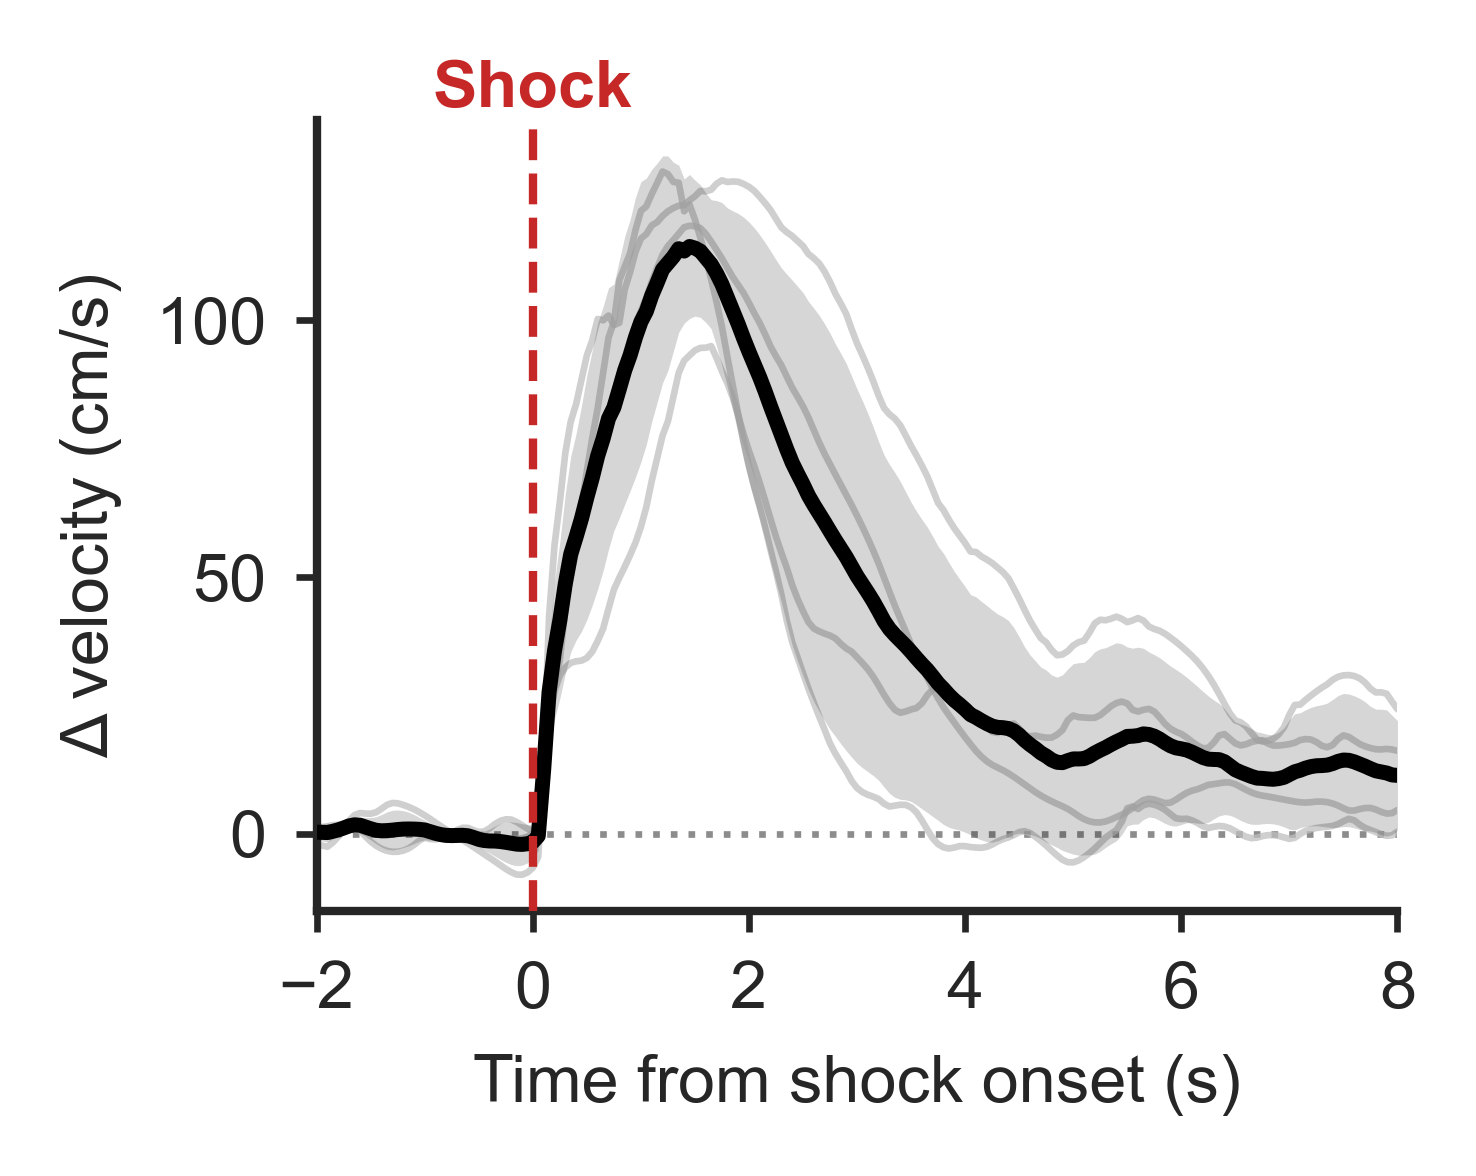

In [20]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("ticks")

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 1,
    "xtick.major.width": 1,
    "ytick.major.width": 1,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

window_pre = 2
window_post = 8
dt = 0.05
rel_t = np.arange(-window_pre, window_post + dt / 2, dt)

files = sorted(processed_dir.glob("processedRotary_*.csv"))

plot_dir = processed_dir / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)

mouse_etas = []

for f in files:
    df = pd.read_csv(f)

    t = df["time_s"].to_numpy()
    vel = df["vel_linear_spline"].to_numpy()

    trials = np.array([
        np.interp(te + rel_t, t, vel, left=np.nan, right=np.nan)
        for te in shock_times
    ])

    # Drop incomplete trials
    trials = trials[~np.isnan(trials).any(axis=1)]

    if len(trials) == 0:
        continue

    # Baseline subtract using pre-shock window
    baseline_mask = rel_t < 0
    baseline = np.nanmean(trials[:, baseline_mask], axis=1, keepdims=True)
    trials_bs = trials - baseline

    # Mouse mean
    mouse_etas.append(np.nanmean(trials_bs, axis=0))

mouse_etas = np.vstack(mouse_etas)


n_mice = mouse_etas.shape[0]

mean_eta = np.nanmean(mouse_etas, axis=0)
sem_eta = np.nanstd(mouse_etas, axis=0, ddof=1) / np.sqrt(n_mice)
ci95 = 1.96 * sem_eta

print("n mice:", n_mice)

fig, ax = plt.subplots(figsize=(2.5, 2), dpi=600)

# Individual mice
for m in mouse_etas:
    ax.plot(
        rel_t,
        m,
        color="0.75",
        linewidth=0.8,
        alpha=0.75,
        zorder=1
    )

# 95% CI
ax.fill_between(
    rel_t,
    mean_eta - ci95,
    mean_eta + ci95,
    color="black",
    alpha=0.16,
    linewidth=0,
    zorder=2
)

# Group mean
ax.plot(
    rel_t,
    mean_eta,
    color="black",
    linewidth=1.8,
    zorder=3
)

# Shock line
ax.axvline(
    0,
    color="#C62828",
    linestyle="--",
    linewidth=1.0,
    zorder=4
)

# Zero response line
ax.axhline(
    0,
    color="0.55",
    linestyle=":",
    linewidth=0.8,
    zorder=0
)

# Shock label
ylim = ax.get_ylim()
ax.text(
    0,
    ylim[1],
    "Shock",
    color="#C62828",
    ha="center",
    va="bottom",
    fontsize=8,
    fontweight="bold"
)

# Axes
ax.set_xlim(-window_pre, window_post)
ax.set_xlabel("Time from shock onset (s)")
ax.set_ylabel("Δ velocity (cm/s)")

# Optional: tidy ticks
ax.set_xticks([-2, 0, 2, 4, 6, 8])
ax.tick_params(axis="both", width=0.8, length=2.5)

sns.despine(ax=ax)
plt.tight_layout()

# Save
fig.savefig(plot_dir / "shock_avg_pub.svg", dpi=600, bbox_inches="tight")
fig.savefig(plot_dir / "shock_avg_pub.png", dpi=600, bbox_inches="tight")

plt.show()

## BUILD + SAVE SUMMARY TABLE FOR TFC
Saves the mean velocity in each epoch (tone, trace, shock, ITI) for each mouse

In [ ]:
summary_rows = []

for f in files:
    df = pd.read_csv(f)
    mouse = f.stem.replace("processedRotary_", "")

    time = df["time_s"].to_numpy()
    vel = df["vel_linear_spline"].to_numpy()

    epoch_vals = {
        "Tone":  mean_in_epoch(time, vel, tone_times, tone_dur),
        "Trace": mean_in_epoch(time, vel, trace_times, trace_dur),
        "Shock": mean_in_epoch(time, vel, shock_times, shock_dur),
        "ITI":   mean_in_epoch(time, vel, ITI_times, ITI_dur),
    }

    for epoch, vals in epoch_vals.items():
        summary_rows.append({
            "mouse": mouse,
            "epoch": epoch,
            "mean_velocity": np.nanmean(vals)
        })

summary_df = pd.DataFrame(summary_rows)

# enforce order
epoch_order = ["Tone", "Trace", "Shock", "ITI"]
summary_df["epoch"] = pd.Categorical(summary_df["epoch"],
                                     categories=epoch_order,
                                     ordered=True)

summary_df = summary_df.sort_values(["mouse", "epoch"])

# save
save_path = plot_dir / "epoch_summary_per_mouse.csv"
summary_df.to_csv(save_path, index=False)

print(f"Saved summary to: {save_path}")


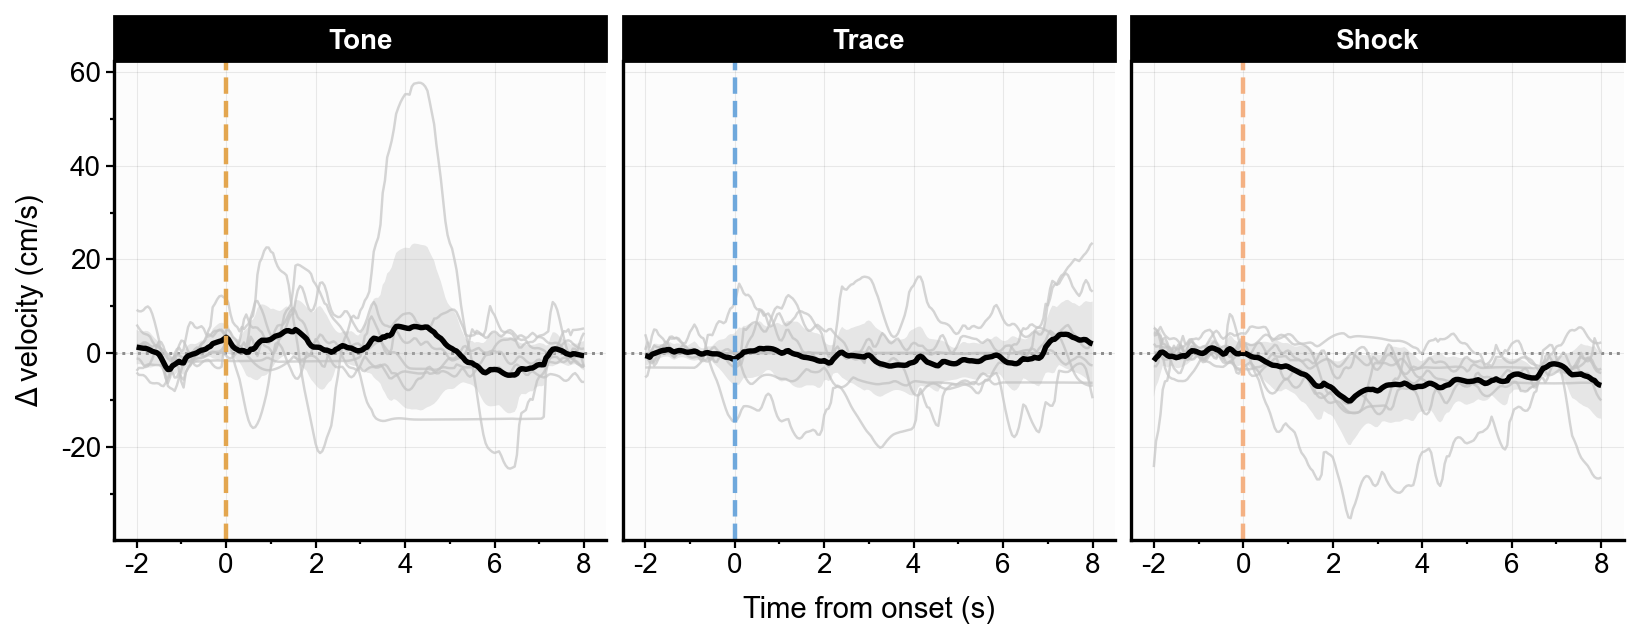

In [66]:
from plotnine import (
    ggplot, aes, geom_line, geom_ribbon, geom_vline, geom_hline, facet_wrap,
    theme_gray, theme, labs, scale_x_continuous, scale_color_manual,
    element_text, element_blank, element_line, element_rect
)


window_pre = 2
window_post = 8
dt = 0.05
rel_t = np.arange(-window_pre, window_post + dt/2, dt)

files = sorted(processed_dir.glob("processedRotary_*.csv"))
files = [f for f in files if "phoebe" not in f.stem]
plot_dir = processed_dir / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)

# Matching palette
EVENT_COLORS = {
    "Tone": "#E3A64F",
    "Trace": "#6FA8DC",
    "Shock": "#F4B183"
}
MOUSE_COLOR = "#C7C7C7"
CI_COLOR = "#BDBDBD"
MEAN_COLOR = "#000000"
PANEL_BG = "#FCFCFC"

event_specs = {
    "Tone": tone_times,
    "Trace": trace_times,
    "Shock": shock_times
}

rows = []

for f in files:
    df = pd.read_csv(f)
    mouse_id = f.stem.replace("processedRotary_", "")

    t = df["time_s"].to_numpy()
    vel = df["vel_linear_spline"].to_numpy()

    for event_name, event_times in event_specs.items():
        trials = np.array([
            np.interp(ev + rel_t, t, vel, left=np.nan, right=np.nan)
            for ev in event_times
        ])

        trials = trials[~np.isnan(trials).any(axis=1)]
        if len(trials) == 0:
            continue

        baseline_mask = rel_t < 0
        baseline = np.nanmean(trials[:, baseline_mask], axis=1, keepdims=True)
        trials_bs = trials - baseline
        mouse_mean = np.nanmean(trials_bs, axis=0)

        rows += [{
            "mouse_id": mouse_id,
            "event": event_name,
            "time": tt,
            "velocity": vv
        } for tt, vv in zip(rel_t, mouse_mean)]

mouse_df = pd.DataFrame(rows)
mouse_df["event"] = pd.Categorical(
    mouse_df["event"], ["Tone", "Trace", "Shock"], ordered=True
)

group_df = (
    mouse_df.groupby(["event", "time"], observed=True)["velocity"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

group_df["sem"] = group_df["std"] / np.sqrt(group_df["count"])
group_df["lower"] = group_df["mean"] - 1.96 * group_df["sem"]
group_df["upper"] = group_df["mean"] + 1.96 * group_df["sem"]
group_df["event"] = pd.Categorical(
    group_df["event"], ["Tone", "Trace", "Shock"], ordered=True
)

# One row per facet for colored onset line
vline_df = pd.DataFrame({
    "event": ["Tone", "Trace", "Shock"],
    "xint": [0, 0, 0]
})
vline_df["event"] = pd.Categorical(
    vline_df["event"], ["Tone", "Trace", "Shock"], ordered=True
)

p = (
    ggplot()

    # zero response line
    + geom_hline(
        yintercept=0,
        color="#8C8C8C",
        linetype="dotted",
        size=.6
    )

    # individual mouse traces
    + geom_line(
        mouse_df,
        aes("time", "velocity", group="mouse_id"),
        color=MOUSE_COLOR,
        alpha=.75,
        size=.5
    )

    # 95% CI
    + geom_ribbon(
        group_df,
        aes("time", ymin="lower", ymax="upper"),
        inherit_aes=False,
        fill=CI_COLOR,
        alpha=.35
    )

    # group mean
    + geom_line(
        group_df,
        aes("time", "mean"),
        inherit_aes=False,
        color=MEAN_COLOR,
        size=1.1
    )

    # onset line, colored by event
    + geom_vline(
        vline_df,
        aes(xintercept="xint", color="event"),
        inherit_aes=False,
        linetype="dashed",
        size=.9
    )

    + scale_color_manual(values=EVENT_COLORS)

    + facet_wrap("~event", nrow=1)

    + scale_x_continuous(breaks=[-2, 0, 2, 4, 6, 8])

    + labs(
        x="Time from onset (s)",
        y="Δ velocity (cm/s)"
    )

    + theme_gray(base_family="Arial", base_size=11)

    + theme(
        figure_size=(8.2, 3.2),
        legend_position="none",

        panel_background=element_rect(fill=PANEL_BG, color=None),
        panel_grid_major=element_line(color="black", alpha=.08, size=.4),
        panel_grid_minor=element_blank(),

        strip_background=element_rect(fill="black", color="black"),
        strip_text=element_text(color="white", weight="bold", size=10),

        axis_line_x=element_line(color="black", size=1.2),
        axis_line_y=element_line(color="black", size=1.2),
        axis_ticks=element_line(color="black", size=.8),

        axis_text=element_text(color="black", size=10),
        axis_title=element_text(color="black", size=10.5)
    )
)

p.save(plot_dir / "tone_trace_shock_avg_plotnine.svg", dpi=600, verbose=False)
p.save(plot_dir / "tone_trace_shock_avg_plotnine.png", dpi=600, verbose=False)

p